In [54]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import altair as alt

In [55]:
# pip install altair

In [66]:
df = pd.read_csv('snow_removal_feature_engineered.csv')

In [57]:
df

,neighborhood,date,daily_request_count,SNOW,PRCP,TMAX,TMIN,TAVG,weekday,is_weekend,...,sqmiles,is_snow_season,is_weekday,lag_1d,lag_3d,rolling_mean_3d,rolling_std_3d,weekofyear,year_minus_1,lag_1y_same_week
0,Allegheny Center,2016-01-13,6,0.14,0.1,-6.1255,-12.575501,-9.125501,Wednesday,False,...,0.208937,1,1,NaN,NaN,NaN,NaN,2,2015,NaN
1,Allegheny Center,2016-02-15,1,4.83,6.7,1.4745,-7.025500,-2.608834,Monday,False,...,0.208937,1,1,6.0,NaN,NaN,NaN,7,2015,NaN
2,Allegheny Center,2016-02-17,1,0.21,0.3,2.4745,-4.825500,-0.810917,Wednesday,False,...,0.208937,1,1,1.0,NaN,NaN,NaN,7,2015,NaN
3,Allegheny Center,2019-01-22,1,0.00,0.0,2.1745,-22.925499,-10.752583,Tuesday,False,...,0.208937,1,1,1.0,6.0,2.666667,2.886751,4,2018,NaN
4,Allegheny Center,2019-03-04,1,0.00,0.0,-2.8255,-9.475500,-5.488000,Monday,False,...,0.208937,1,1,1.0,1.0,1.000000,0.000000,10,2018,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9797,Windgap,2025-01-15,1,0.42,6.5,10.5745,1.474500,5.895334,Wednesday,False,...,0.416934,1,1,1.0,1.0,1.000000,0.000000,3,2024,NaN
9798,Windgap,2025-01-16,1,0.42,6.5,10.5745,1.474500,5.895334,Thursday,False,...,0.416934,1,1,1.0,1.0,1.000000,0.000000,3,2024,NaN
9799,Windgap,2025-01-21,1,0.42,6.5,10.5745,1.474500,5.895334,Tuesday,False,...,0.416934,1,1,1.0,1.0,1.000000,0.000000,4,2024,NaN
9800,Windgap,2025-01-22,2,0.42,6.5,10.5745,1.474500,5.895334,Wednesday,False,...,0.416934,1,1,1.0,1.0,1.000000,0.000000,4,2024,NaN


In [49]:
df.columns

Index(['neighborhood', 'date', 'daily_request_count', 'SNOW', 'PRCP', 'TMAX',
       'TMIN', 'TAVG', 'weekday', 'is_weekend', 'year', 'month',
       'avg_daily_car_traffic_2017_2021', 'sqmiles', 'is_snow_season',
       'is_weekday', 'lag_1d', 'lag_3d', 'rolling_mean_3d', 'rolling_std_3d',
       'weekofyear', 'year_minus_1', 'lag_1y_same_week'],
      dtype='object')

In [50]:
df.isna().sum()

neighborhood                          0
date                                  0
daily_request_count                   0
SNOW                                  0
PRCP                                  0
TMAX                                  0
TMIN                                  0
TAVG                                  0
weekday                               0
is_weekend                            0
year                                  0
month                                 0
avg_daily_car_traffic_2017_2021    1706
sqmiles                               7
is_snow_season                        0
is_weekday                            0
lag_1d                               91
lag_3d                              273
rolling_mean_3d                     273
rolling_std_3d                      273
weekofyear                            0
year_minus_1                          0
lag_1y_same_week                   5913
dtype: int64

In [51]:
df.dtypes

neighborhood                        object
date                                object
daily_request_count                  int64
SNOW                               float64
PRCP                               float64
TMAX                               float64
TMIN                               float64
TAVG                               float64
weekday                             object
is_weekend                            bool
year                                 int64
month                                int64
avg_daily_car_traffic_2017_2021    float64
sqmiles                            float64
is_snow_season                       int64
is_weekday                           int64
lag_1d                             float64
lag_3d                             float64
rolling_mean_3d                    float64
rolling_std_3d                     float64
weekofyear                           int64
year_minus_1                         int64
lag_1y_same_week                   float64
dtype: obje

In [ ]:
# df['date'] = pd.to_datetime(df['date'])
# df = df.groupby('date').sum()
# df = df.asfreq('D')   
# df = df.fillna(0)


In [24]:
df.daily_request_count.value_counts()

daily_request_count
1     4684
2     1738
3      948
4      572
5      373
      ... 
83       1
75       1
55       1
76       1
61       1
Name: count, Length: 77, dtype: int64

In [27]:
selected_cols = [
    'daily_request_count',
    'SNOW',
    'PRCP',
    'TMAX',
    'TMIN',
    'TAVG',
    'is_weekend',
    'month',
    'is_snow_season',
    'lag_1y_same_week',
    'lag_1d',
    'rolling_mean_3d',
    'rolling_std_3d'
]

corr_df = df[selected_cols]
corr_matrix = corr_df.corr().stack().reset_index()
corr_matrix.columns = ['feature_1', 'feature_2', 'correlation']

base = alt.Chart(corr_matrix).mark_rect().encode(
    x=alt.X('feature_1:N', title='Feature 1', sort=None),
    y=alt.Y('feature_2:N', title='Feature 2', sort=None),
    color=alt.Color('correlation:Q', scale=alt.Scale(domain=[-1, 1], scheme='redblue')),
    tooltip=['feature_1', 'feature_2', 'correlation']
)

text = alt.Chart(corr_matrix).mark_text(size=12).encode(
    x=alt.X('feature_1:N', sort=None),
    y=alt.Y('feature_2:N', sort=None),
    text=alt.Text('correlation:Q', format='.2f'),
    color=alt.condition(
        "datum.correlation > 0.5 || datum.correlation < -0.5",
        alt.value('white'),
        alt.value('black')
    )
)

heatmap_with_labels = (base + text).properties(
    width=700,
    height=700,
    title='Correlation Matrix with Values (Altair Heatmap)'
)

heatmap_with_labels


c:\Users\moidu\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
c:\Users\moidu\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.LayerChart(...)

In [59]:
df.date.is_unique

AttributeError: 'DataFrame' object has no attribute 'date'

In [68]:
# # Import libraries
# import pandas as pd
# from statsmodels.tsa.statespace.sarimax import SARIMAX
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np
# import matplotlib.pyplot as plt

# # Step 1: Data Preparation

# # 1.1 Ensure 'date' is datetime
# df['date'] = pd.to_datetime(df['date'])

# # 1.2 Group by 'date' and sum all numerical features
# df = df.groupby('date').sum()

# # 1.3 Ensure datetime index and daily frequency
# df.index = pd.to_datetime(df.index)
# df = df.asfreq('D')    # Resample to daily frequency
# df = df.fillna(0)      # Fill missing days with 0

# # Step 2: Feature Selection

# selected_cols = [
#     'daily_request_count',
#     'SNOW',
#     'PRCP',
#     'TMAX',
#     'TMIN',
#     'TAVG',
#     'is_weekend',
#     'month',
#     'is_snow_season',
#     'lag_1y_same_week',
#     'lag_1d',
#     'rolling_mean_3d',
#     'rolling_std_3d'
# ]

# # Make sure we work only with selected features
# data = df[selected_cols].copy()

# # Step 3: Train-Test Split

# train = data[data.index.year <= 2022]
# test = data[data.index.year >= 2023]

# # Step 4: Separate Target and Features

# y_train = train['daily_request_count']
# X_train = train.drop(columns=['daily_request_count']).astype(float)

# y_test = test['daily_request_count']
# X_test = test.drop(columns=['daily_request_count']).astype(float)

# # Step 5: Build and Fit SARIMAX Model

# sarimax_model = SARIMAX(
#     y_train,
#     exog=X_train,
#     order=(1, 0, 1),           # (p,d,q)
#     seasonal_order=(1, 1, 1, 52),  # (P,D,Q,s) for weekly seasonality
#     enforce_stationarity=False,
#     enforce_invertibility=False
# )

# sarimax_fit = sarimax_model.fit(disp=False, method='powell')
# print(sarimax_fit.summary())

# # Step 6: Forecast on Test Set

# y_pred = sarimax_fit.predict(
#     start=X_test.index[0],
#     end=X_test.index[-1],
#     exog=X_test
# )

# # Optional: Clip negative predictions to 0
# y_pred = np.clip(y_pred, 0, None)

# # Step 7: Evaluation Metrics

# mae = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# print(f"\nModel Evaluation:")
# print(f"Mean Absolute Error (MAE): {mae:.2f}")
# print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# # Step 8: Plot Results

# plt.figure(figsize=(15,6))
# plt.plot(y_train.index, y_train, label='Train Actual', color='blue')
# plt.plot(y_test.index, y_test, label='Test Actual', color='green')
# plt.plot(y_test.index, y_pred, label='Forecast', color='red', linestyle='--')
# plt.title('SARIMAX Forecast of Snow Removal Requests')
# plt.xlabel('Date')
# plt.ylabel('Daily Requests')
# plt.legend()
# plt.grid(True)
# plt.show()


In [69]:
# Select only strongest features
selected_cols_small = [
    'daily_request_count',
    'SNOW',
    'lag_1d',
    'rolling_mean_3d',
    'is_snow_season'
]

# Prepare data
data = df[selected_cols_small].copy()

train = data[data.index.year <= 2022]
test = data[data.index.year >= 2023]

y_train = train['daily_request_count']
X_train = train.drop(columns=['daily_request_count']).astype(float)

y_test = test['daily_request_count']
X_test = test.drop(columns=['daily_request_count']).astype(float)

# Build model
sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Time the fitting
import time
start = time.time()

sarimax_fit = sarimax_model.fit(disp=False, method='powell')

end = time.time()
print(f"Model training completed in {end-start:.2f} seconds.")

# Forecast
y_pred = sarimax_fit.predict(
    start=X_test.index[0],
    end=X_test.index[-1],
    exog=X_test
)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Model training completed in 289.48 seconds.
MAE: 8.55
RMSE: 17.96


In [80]:
# Import
from prophet import Prophet
import pandas as pd
import numpy as np

# Prepare data for Prophet
prophet_train = pd.DataFrame({
    'ds': y_train.index,
    'y': y_train.values
})

prophet_test = pd.DataFrame({
    'ds': y_test.index
})

# Initialize Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive'
)

# Fit model
prophet_model.fit(prophet_train)

# Predict
forecast = prophet_model.predict(prophet_test)

# Extract predictions
y_pred_prophet = forecast['yhat'].values

# Evaluation
mae_prophet = mean_absolute_error(y_test, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_test, y_pred_prophet))

print(f"[Prophet] MAE: {mae_prophet:.2f}")
print(f"[Prophet] RMSE: {rmse_prophet:.2f}")


01:32:18 - cmdstanpy - INFO - Chain [1] start processing
01:32:18 - cmdstanpy - INFO - Chain [1] done processing


[Prophet] MAE: 17.69
[Prophet] RMSE: 38.67


In [85]:
# Import
import lightgbm as lgb

# Prepare datasets
train_lgb = X_train.copy()
train_lgb['target'] = y_train

test_lgb = X_test.copy()

# Define model
lgbm_model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Train
lgbm_model.fit(train_lgb.drop(columns=['target']), train_lgb['target'])

# Predict
y_pred_lgbm = lgbm_model.predict(test_lgb)

# Evaluation
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))

print(f"[LightGBM] MAE: {mae_lgbm:.2f}")
print(f"[LightGBM] RMSE: {rmse_lgbm:.2f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000642 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 317
[LightGBM] [Info] Number of data points in the train set: 2811, number of used features: 4
[LightGBM] [Info] Start training from score 10.549271
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

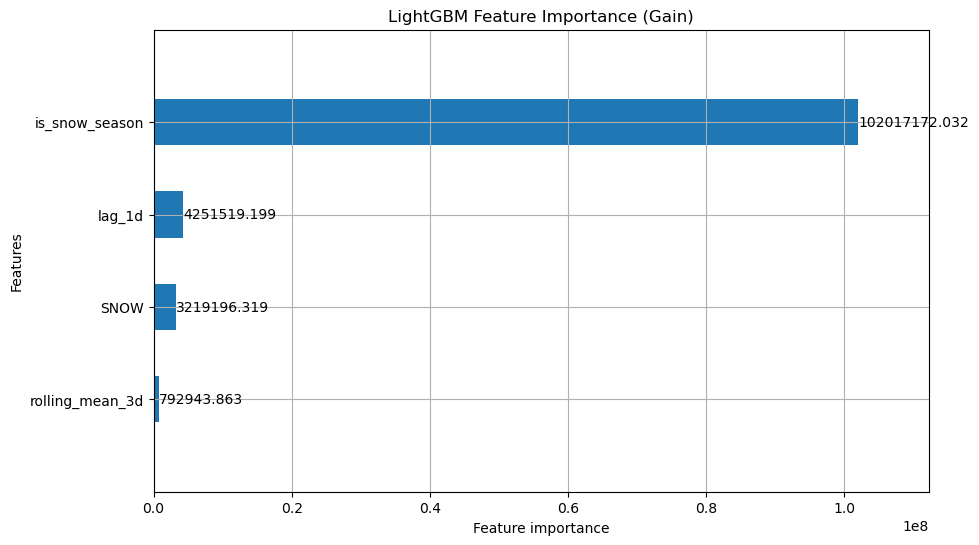

In [86]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# Plot feature importance
lgb.plot_importance(
    lgbm_model,
    importance_type='gain',  # 'gain' shows how much each feature improves the model
    max_num_features=10,      # top 10 features
    height=0.5,
    figsize=(10, 6),
    title="LightGBM Feature Importance (Gain)"
)
plt.grid(True)
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

# Define model
lgbm_model = lgb.LGBMRegressor(
    objective='regression',
    random_state=42
)

# Define grid to search
param_grid = {
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [3, 4, 5],
    'num_leaves': [7, 15, 31],
    'n_estimators': [500, 1000],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',  # because lower MAE is better
    cv=3,  # 3-fold cross-validation
    verbose=2,
    n_jobs=-1  # use all CPU cores
)

# Fit
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters Found:")
print(grid_search.best_params_)

# Best score (negated, so take absolute value)
print(f"Best MAE: {abs(grid_search.best_score_):.2f}")

# Best model
best_lgbm_model = grid_search.best_estimator_


Fitting 3 folds for each of 486 candidates, totalling 1458 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000330 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 317
[LightGBM] [Info] Number of data points in the train set: 2811, number of used features: 4
[LightGBM] [Info] Start training from score 10.549271
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Predict on both train and test
y_train_pred = lgbm_model.predict(X_train)
y_test_pred = lgbm_model.predict(X_test)

# Compute Train Metrics
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)
mape_train = np.mean(np.abs((y_train - y_train_pred) / np.maximum(1, y_train))) * 100  # protect against div/0

# Compute Test Metrics
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)
mape_test = np.mean(np.abs((y_test - y_test_pred) / np.maximum(1, y_test))) * 100

# Build DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R-squared (R²)'],
    'Train': [mae_train, rmse_train, mape_train, r2_train],
    'Test': [mae_test, rmse_test, mape_test, r2_test]
})

# Display neatly
print(metrics_df.to_string(index=False))


        Metric     Train      Test
           MAE  2.291325  2.477525
          RMSE 20.709978 14.830197
      MAPE (%)  6.914802  6.850815
R-squared (R²)  0.899177  0.863395


In [91]:
import altair as alt
import pandas as pd

# Prepare plot DataFrame
plot_df = pd.DataFrame({
    'date': y_test.index,
    'Actual Requests': y_test.values,
    'Predicted Requests': y_pred
})

# Melt to long format
plot_df_melt = plot_df.melt('date', var_name='Type', value_name='Requests')

# Filter only snow season months (November to March)
plot_df_melt_zoomed = plot_df_melt[
    (plot_df_melt['date'].dt.month <= 3) | (plot_df_melt['date'].dt.month >= 11)
]

# Better color scheme
color_scale = alt.Scale(domain=['Actual Requests', 'Predicted Requests'],
                        range=['#1f77b4', '#ff7f0e'])  # Blue and Orange

# Build Altair chart
zoomed_chart_better = alt.Chart(plot_df_melt_zoomed).mark_line(
    interpolate='monotone',  # smooth curves
    strokeWidth=2
).encode(
    x=alt.X('date:T', title='Date', axis=alt.Axis(labelAngle=-45)),
    y=alt.Y('Requests:Q', title='Snow Removal Requests', scale=alt.Scale(zero=True)),
    color=alt.Color('Type:N', scale=color_scale, title='Legend'),
    tooltip=[
        alt.Tooltip('date:T', title='Date'),
        alt.Tooltip('Type:N', title='Type'),
        alt.Tooltip('Requests:Q', title='Requests')
    ]
).properties(
    width=900,
    height=400,
    title=alt.TitleParams(
        text='Zoomed Forecast vs Actual Snow Removal Requests (Nov–Mar, 2023-2024)',
        fontSize=18,
        font='Arial',
        anchor='middle'
    )
).configure_axis(
    grid=True,
    gridOpacity=0.3
).configure_legend(
    titleFontSize=14,
    labelFontSize=12
).interactive()

zoomed_chart_better


c:\Users\moidu\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

In [130]:
import pandas as pd
import numpy as np

df = pd.read_csv('snow_removal_feature_engineered.csv')

# Assume your main DataFrame is called df
# And it has columns: 'date', 'daily_request_count', 'SNOW', 'PRCP', 'TAVG', 'TMIN', 'TMAX', 'is_snow_season', etc.

# 1. Make sure 'date' is datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# 2. Fill missing values first (safe step)
df = df.fillna(0)

# 3. Existing features (already present)
# - 'daily_request_count'
# - 'SNOW'
# - 'lag_1d'
# - 'rolling_mean_3d'
# - 'is_snow_season'

# 4. NEW Features to Add

# a) Lag features
df['lag_1d'] = df['daily_request_count'].shift(1).fillna(0)
df['lag_3d'] = df['daily_request_count'].shift(3).fillna(0)


# b) Rolling features
df['rolling_mean_3d'] = df['daily_request_count'].rolling(window=3).mean().fillna(0)
df['rolling_sum_snow_3d'] = df['SNOW'].rolling(window=3).sum().fillna(0)

# c) Calendar features
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek  # 0=Monday, ..., 6=Sunday
df['is_weekend'] = df['dayofweek'] >= 5

# d) Weather features
# (Already in your dataset: 'SNOW', 'PRCP', 'TAVG', 'TMIN', 'TMAX')

# 5. Final selected columns
selected_cols_expanded = [
    'daily_request_count',   # target
    'SNOW',
    # 'PRCP',
     'TAVG',
    #  'TMIN',
    'TMAX',
    'lag_1d',
    # 'lag_3d',
     'rolling_mean_3d',
    'rolling_sum_snow_3d',
     'month',
    #  'dayofweek',
    #  'is_weekend',
     'is_snow_season'
]

# 6. Create final feature dataset
data = df[selected_cols_expanded].copy()

print("✅ Feature expansion completed. Shape:", data.shape)
data.head()


✅ Feature expansion completed. Shape: (9802, 9)


,daily_request_count,SNOW,TAVG,TMAX,lag_1d,rolling_mean_3d,rolling_sum_snow_3d,month,is_snow_season
date,,,,,,,,,
2016-01-13,6,0.14,-9.125501,-6.1255,0.0,0.000000,0.00,1,1
2016-02-15,1,4.83,-2.608834,1.4745,6.0,0.000000,0.00,2,1
2016-02-17,1,0.21,-0.810917,2.4745,1.0,2.666667,5.18,2,1
2019-01-22,1,0.00,-10.752583,2.1745,1.0,1.000000,5.04,1,1
2019-03-04,1,0.00,-5.488000,-2.8255,1.0,1.000000,0.21,3,1


In [131]:
# 1. Import necessary libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import pandas as pd
import numpy as np

# 2. Train-Test Split
train = data[data.index.year <= 2022]
test = data[data.index.year >= 2023]

# Separate target and features
y_train = train['daily_request_count']
X_train = train.drop(columns=['daily_request_count']).astype(float)

y_test = test['daily_request_count']
X_test = test.drop(columns=['daily_request_count']).astype(float)

# 3. Build and Train LightGBM Model
lgbm_model = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',
    learning_rate=0.01,
    n_estimators=1000,
    max_depth=5,
    num_leaves=15,                # reduce leaves
    subsample=0.8,                
    colsample_bytree=0.8,
    reg_alpha=1.0,                # L1 regularization (adds sparsity)
    reg_lambda=2.0,               # L2 regularization (smooths weights)
    min_child_samples=50,         # minimum samples in one leaf
    random_state=42
)


# Timing training
import time
start = time.time()

lgbm_model.fit(X_train, y_train)

end = time.time()
print(f"✅ Model trained in {end - start:.2f} seconds.")

# 4. Predict
y_train_pred = lgbm_model.predict(X_train)
y_test_pred = lgbm_model.predict(X_test)

# 5. Evaluate
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)
mape_train = np.mean(np.abs((y_train - y_train_pred) / np.maximum(1, y_train))) * 100

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)
mape_test = np.mean(np.abs((y_test - y_test_pred) / np.maximum(1, y_test))) * 100

# 6. Display Results
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R-squared (R²)'],
    'Train': [mae_train, rmse_train, mape_train, r2_train],
    'Test': [mae_test, rmse_test, mape_test, r2_test]
})

print("\n📊 Performance Metrics (Expanded Features):")
print(metrics_df.to_string(index=False))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001774 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1009
[LightGBM] [Info] Number of data points in the train set: 7773, number of used features: 7
[LightGBM] [Info] Start training from score 3.815001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

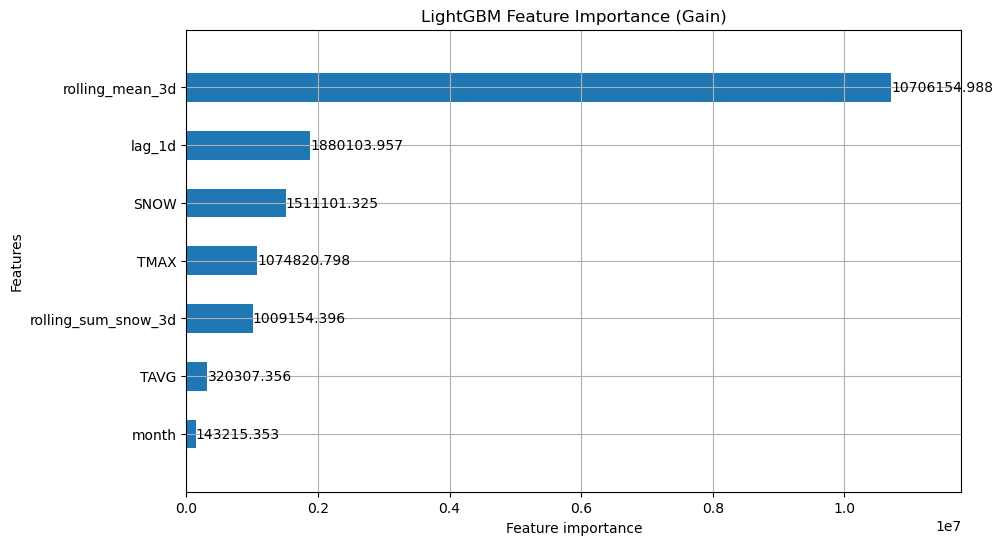

In [132]:
# Plot feature importance
lgb.plot_importance(
    lgbm_model,
    importance_type='gain',  # 'gain' shows how much each feature improves the model
    max_num_features=10,      # top 10 features
    height=0.5,
    figsize=(10, 6),
    title="LightGBM Feature Importance (Gain)"
)
plt.grid(True)
plt.show()
